# Egyptian Used Car Price Intelligence

## From raw listings to a useful price estimate

This educational notebook investigates real Egyptian used-car listings. We will understand the data, clean it, explore the market, compare three classical Machine Learning models, inspect errors, and save the best approach for Streamlit apps.

**Main question:** Can we predict a reasonable advertised price from a car's characteristics?


## 1. Business questions

1. What does the Egyptian used-car listing market look like?
2. Which car characteristics are related to price?
3. Do mileage and car age appear related to price?
4. Which makes occupy higher price ranges?
5. Which features are useful for prediction?
6. Which of three simple regression models performs best?

The target is the advertised listing price, not a confirmed final sale price.


## 2. Import libraries

We use only the libraries needed for data work, plots, classical Machine Learning, evaluation, and model saving.


In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
REFERENCE_YEAR = 2024


## 3. Load the dataset

The CSV has already been supplied with the project. The loading step is deliberately simple.


In [2]:
path = "data/used_cars.csv"
df = pd.read_csv(path)

df.head()


,Name,Price,Color,Mileage,Make,Model,City,Date Displayed,Automatic Transmission,Air Conditioner,Power Steering,Remote Control,Item URL
0,Kia Sportage 2024,"2,800,000 EGP",Dark grey,300 Km,Kia,Sportage,Tagamo3 - New Cairo,2024-02-16,Yes,Yes,Yes,Yes,https://eg.hatla2ee.com/en/car/kia/sportage/62...
1,Chery Arrizo 5 2022,NaN,Bronze,"86,000 Km",Chery,Arrizo 5,Nasr city,2024-02-16,Yes,Yes,Yes,Yes,https://eg.hatla2ee.com/en/car/chery/Arrizo-5/...
2,Fiat Tipo 2021,"1,200,000 EGP",Petroleum,"131,000 Km",Fiat,Tipo,Kafr el-Dawwar,2024-02-16,Yes,Yes,Yes,Yes,https://eg.hatla2ee.com/en/car/fiat/tipo/6286701
3,Hyundai Tucson Turbo GDI 2021,"2,050,000 EGP",Black,"125,000 Km",Hyundai,Tucson Turbo GDI,Nasr city,2024-02-16,Yes,Yes,Yes,Yes,https://eg.hatla2ee.com/en/car/hyundai/Tucson-...
4,BMW X1 2018,"2,050,000 EGP",Gray,"84,000 Km",BMW,X1,Cairo,2024-02-16,Yes,Yes,Yes,Yes,https://eg.hatla2ee.com/en/car/bmw/x1/6254123


In [3]:
print("Rows and columns:", df.shape)
df.info()


Rows and columns: (33559, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33559 entries, 0 to 33558
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Name                    33559 non-null  object
 1   Price                   32625 non-null  object
 2   Color                   33559 non-null  object
 3   Mileage                 31440 non-null  object
 4   Make                    33559 non-null  object
 5   Model                   33559 non-null  object
 6   City                    33559 non-null  object
 7   Date Displayed          33559 non-null  object
 8   Automatic Transmission  33559 non-null  object
 9   Air Conditioner         33559 non-null  object
 10  Power Steering          33559 non-null  object
 11  Remote Control          33559 non-null  object
 12  Item URL                33559 non-null  object
dtypes: object(13)
memory usage: 3.3+ MB


In [4]:
df.describe(include="all").T


,count,unique,top,freq
Name,33559,4158,Nissan Sunny 2022,647
Price,32625,828,"650,000 EGP",969
Color,33559,24,Black,6532
Mileage,31440,1084,"200,000 Km",1317
Make,33559,101,Hyundai,3800
Model,33559,889,Sunny,1868
City,33559,103,Cairo,3983
Date Displayed,33559,124,2024-02-16,12333
Automatic Transmission,33559,2,Yes,21289
Air Conditioner,33559,2,Yes,20643


## 4. Understand the dataset

Each row is a scraped listing. The actual supplied columns include name, price, mileage, make, model, city, colour, date, equipment flags, and URL.


In [5]:
data_dictionary = pd.DataFrame(
    {
        "Column": df.columns,
        "Meaning": [
            "Listing title; usually includes the model year.",
            "Advertised price stored as text with EGP.",
            "Exterior colour.",
            "Mileage stored as text with Km.",
            "Vehicle make or brand.",
            "Vehicle model.",
            "Listing location.",
            "Date displayed on the listing.",
            "Automatic transmission flag.",
            "Air conditioner flag.",
            "Power steering flag.",
            "Remote control flag.",
            "Source listing URL.",
        ],
    }
)

data_dictionary


,Column,Meaning
0,Name,Listing title; usually includes the model year.
1,Price,Advertised price stored as text with EGP.
2,Color,Exterior colour.
3,Mileage,Mileage stored as text with Km.
4,Make,Vehicle make or brand.
5,Model,Vehicle model.
6,City,Listing location.
7,Date Displayed,Date displayed on the listing.
8,Automatic Transmission,Automatic transmission flag.
9,Air Conditioner,Air conditioner flag.


## 5. Data quality check

Before changing data, we check missing values, duplicates, data types, and examples of the text-formatted numeric fields. We make cleaning decisions only after seeing the actual data.


In [6]:
quality_check = pd.DataFrame(
    {
        "Data type": df.dtypes,
        "Missing values": df.isnull().sum(),
        "Unique values": df.nunique(),
    }
)

quality_check


,Data type,Missing values,Unique values
Name,object,0,4158
Price,object,934,828
Color,object,0,24
Mileage,object,2119,1084
Make,object,0,101
Model,object,0,889
City,object,0,103
Date Displayed,object,0,124
Automatic Transmission,object,0,2
Air Conditioner,object,0,2


In [7]:
print("Exact duplicate rows:", df.duplicated().sum())
print("Repeated listing URLs:", df["Item URL"].duplicated().sum())

df[["Name", "Price", "Mileage", "Date Displayed"]].sample(8, random_state=RANDOM_STATE)


Exact duplicate rows: 11507
Repeated listing URLs: 11511


,Name,Price,Mileage,Date Displayed
573,Renault Megane 2017,"795,000 EGP","190,000 Km",2024-02-15
17161,Mitsubishi Lancer Puma 2007,"550,000 EGP","220,000 Km",2024-02-02
7100,Toyota Corolla 2003,"400,000 EGP","250,000 Km",2024-01-11
32565,Chery Arrizo 5 2022,NaN,"86,000 Km",2024-02-16
758,Jeep Renegade 2019,"1,560,000 EGP","133,150 Km",2024-02-14
24541,Fiat Uno 2001,"150,000 EGP","180,000 Km",2024-02-16
17315,Audi A4 2007,"650,000 EGP","253,000 Km",2024-01-29
5485,Opel Astra 2014,"685,000 EGP","137,000 Km",2024-01-23


## 6. Data cleaning

The data check reveals repeated scraped rows and repeated listing URLs. We keep one record per URL.

Price and mileage are text, so we extract numeric values. Missing price means there is no target to train on, and one row has no usable model year. Both must be removed.

Inspection also reveals two prices below EGP 20,000, including a 2024 Nissan Sunny at EGP 1,060. These values are implausible data-entry errors, so we remove only those two rows. We keep missing mileage because the later training pipeline can impute it using the training-set median.

We do not automatically remove very expensive or high-mileage cars; they may be genuine listings and represent real market variation.


In [8]:
raw_rows = len(df)

df_clean = df.drop_duplicates().copy()
after_exact_duplicates = len(df_clean)

df_clean = df_clean.drop_duplicates(subset="Item URL").copy()
after_url_duplicates = len(df_clean)

df_clean["price"] = pd.to_numeric(
    df_clean["Price"].str.replace(",", "", regex=False).str.extract(r"(\d+)")[0],
    errors="coerce",
)

df_clean["mileage"] = pd.to_numeric(
    df_clean["Mileage"].str.replace(",", "", regex=False).str.extract(r"(\d+)")[0],
    errors="coerce",
)

# The last four-digit year in the title is used as the model year.
df_clean["year"] = pd.to_numeric(
    df_clean["Name"].str.extract(r"((?:19|20)\d{2})(?!.*(?:19|20)\d{2})")[0],
    errors="coerce",
)

rows_before_missing_drop = len(df_clean)
df_clean = df_clean.dropna(subset=["price", "year"]).copy()
rows_after_missing_drop = len(df_clean)

very_low_price_rows = (df_clean["price"] < 20_000).sum()
df_clean = df_clean[df_clean["price"] >= 20_000].copy()

cleaning_summary = pd.DataFrame(
    {
        "Step": [
            "Raw scraped rows",
            "After removing exact duplicates",
            "After keeping one row per URL",
            "After removing missing price or year",
            "After removing prices below EGP 20,000",
        ],
        "Rows": [
            raw_rows,
            after_exact_duplicates,
            after_url_duplicates,
            rows_after_missing_drop,
            len(df_clean),
        ],
    }
)

cleaning_summary


,Step,Rows
0,Raw scraped rows,33559
1,After removing exact duplicates,22052
2,After keeping one row per URL,22048
3,After removing missing price or year,21976
4,"After removing prices below EGP 20,000",21974


In [9]:
df_clean[["Price", "price", "Mileage", "mileage", "Name", "year"]].head(10)


,Price,price,Mileage,mileage,Name,year
0,"2,800,000 EGP",2800000.0,300 Km,300.0,Kia Sportage 2024,2024.0
2,"1,200,000 EGP",1200000.0,"131,000 Km",131000.0,Fiat Tipo 2021,2021.0
3,"2,050,000 EGP",2050000.0,"125,000 Km",125000.0,Hyundai Tucson Turbo GDI 2021,2021.0
4,"2,050,000 EGP",2050000.0,"84,000 Km",84000.0,BMW X1 2018,2018.0
5,"700,000 EGP",700000.0,"75,000 Km",75000.0,Chevrolet Optra 2021,2021.0
6,"700,000 EGP",700000.0,"25,000 Km",25000.0,Chery Arrizo 5 2021,2021.0
7,"1,950,000 EGP",1950000.0,"33,000 Km",33000.0,Kia Sportage 2022,2022.0
8,"400,000 EGP",400000.0,"238,000 Km",238000.0,Hyundai Verna 2014,2014.0
9,"870,000 EGP",870000.0,"99,000 Km",99000.0,Ford Focus 2018,2018.0
10,"575,000 EGP",575000.0,"262,000 Km",262000.0,Nissan Tiida 2011,2011.0


## 7. Target variable analysis: price

Regression needs a numeric target. We now inspect its range, typical value, and distribution shape.


In [10]:
price_summary = df_clean["price"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)
price_summary


count    2.197400e+04
mean     8.476999e+05
std      9.319988e+05
min      2.000000e+04
1%       5.000000e+04
5%       1.400000e+05
25%      3.600000e+05
50%      6.150000e+05
75%      9.500000e+05
95%      2.350000e+06
99%      4.600000e+06
max      2.000000e+07
Name: price, dtype: float64

## 8. Exploratory Data Analysis

Every chart below answers a market question. This investigation happens before modelling so we can explain the data rather than report a score only.


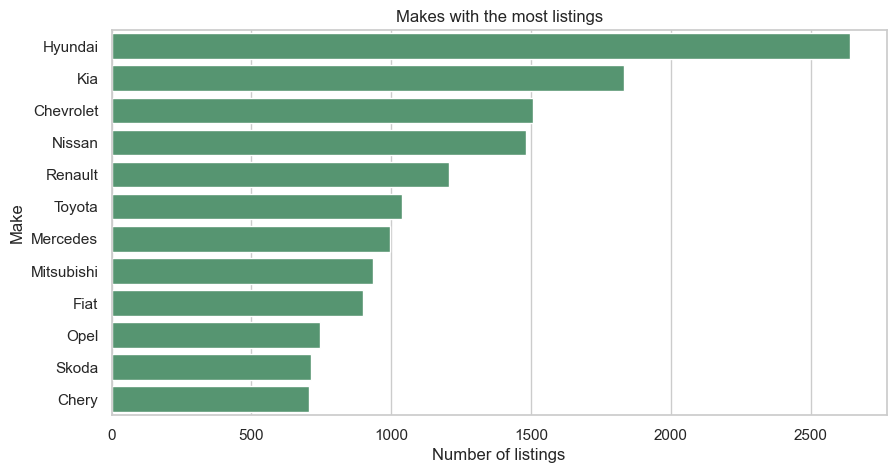

,Listings
Make,
Hyundai,2639
Kia,1831
Chevrolet,1508
Nissan,1481
Renault,1207
Toyota,1038
Mercedes,996
Mitsubishi,933
Fiat,897


In [12]:
top_makes = df_clean["Make"].value_counts().head(12)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_makes.values, y=top_makes.index, color="#4c9f70")
plt.title("Makes with the most listings")
plt.xlabel("Number of listings")
plt.ylabel("Make")
plt.show()

top_makes.to_frame("Listings")


### Interpretation

Listing volume is concentrated among a small number of makes. A model normally learns more reliable patterns for makes and models with many training examples.


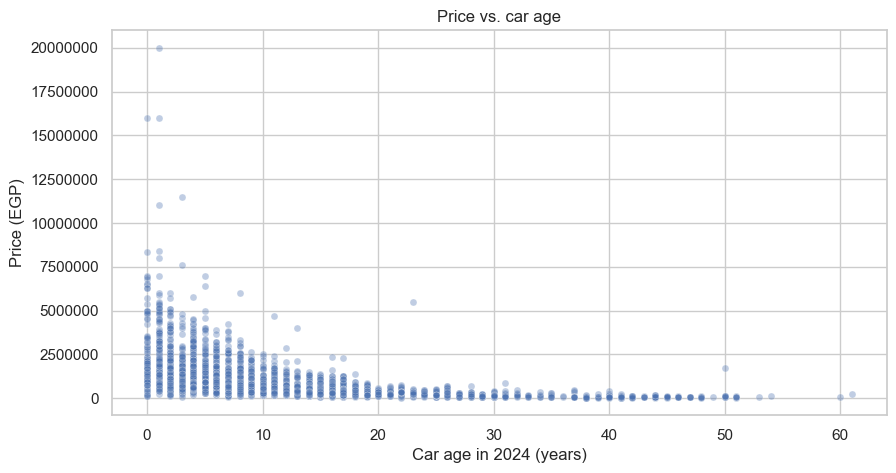

In [13]:
df_clean["car_age_for_eda"] = REFERENCE_YEAR - df_clean["year"]
plot_sample = df_clean.sample(min(5000, len(df_clean)), random_state=RANDOM_STATE)

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=plot_sample,
    x="car_age_for_eda",
    y="price",
    alpha=0.35,
    s=25,
)
plt.title("Price vs. car age")
plt.xlabel("Car age in 2024 (years)")
plt.ylabel("Price (EGP)")
plt.ticklabel_format(style="plain", axis="y")
plt.show()


### Interpretation

This plot shows whether older cars generally occupy lower price ranges. A wide vertical spread at the same age is expected because make, model, mileage, condition, and equipment also influence price.


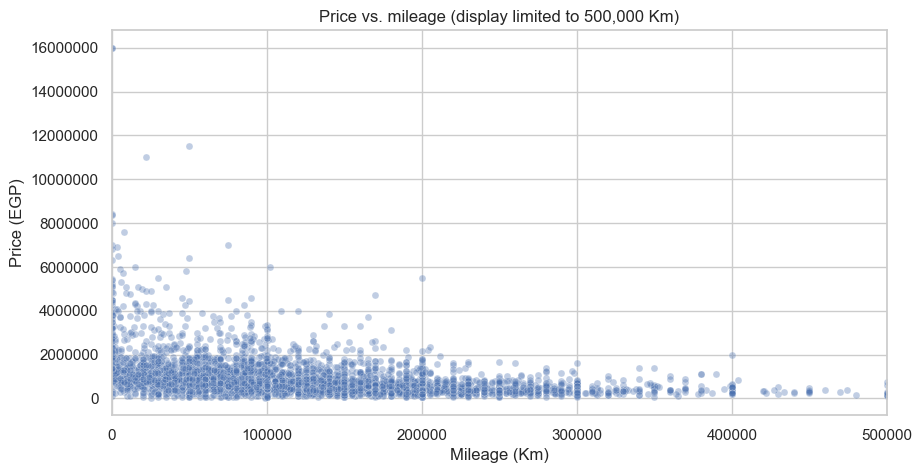

In [14]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=plot_sample,
    x="mileage",
    y="price",
    alpha=0.35,
    s=25,
)
plt.xlim(0, 500_000)
plt.title("Price vs. mileage (display limited to 500,000 Km)")
plt.xlabel("Mileage (Km)")
plt.ylabel("Price (EGP)")
plt.ticklabel_format(style="plain", axis="y")
plt.show()


### Interpretation

Mileage can be associated with lower price, but it is not the only driver. The x-axis display limit makes the main market readable; it does not remove high-mileage records from the data.


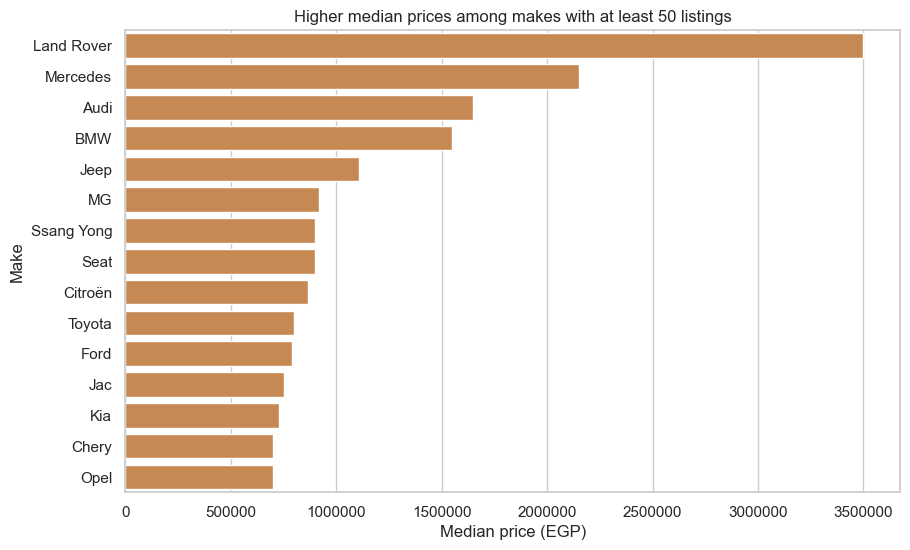

,median_price,listings
Make,,
Land Rover,3500000.0,51
Mercedes,2150000.0,996
Audi,1650000.0,104
BMW,1550000.0,680
Jeep,1110000.0,270
MG,920000.0,512
Ssang Yong,900000.0,59
Seat,900000.0,166
Citroën,865000.0,236


In [15]:
brand_stats = (
    df_clean.groupby("Make")
    .agg(median_price=("price", "median"), listings=("price", "size"))
    .query("listings >= 50")
    .sort_values("median_price", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=brand_stats, x="median_price", y=brand_stats.index, color="#d98841")
plt.title("Higher median prices among makes with at least 50 listings")
plt.xlabel("Median price (EGP)")
plt.ylabel("Make")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

brand_stats


### Interpretation

Median price is more robust than mean price when values are skewed. This chart describes price ranges in these listings; it does not prove that brand alone causes the difference.


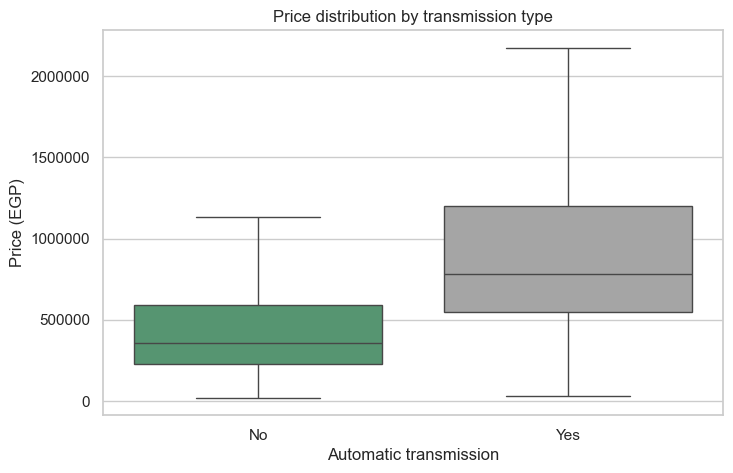

,Median price
Automatic Transmission,
No,360000.0
Yes,780000.0


In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_clean,
    x="Automatic Transmission",
    y="price",
    order=["No", "Yes"],
    showfliers=False,
    hue="Automatic Transmission",
    legend=False,
    palette=["#a5a5a5", "#4c9f70"],
)
plt.title("Price distribution by transmission type")
plt.xlabel("Automatic transmission")
plt.ylabel("Price (EGP)")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

df_clean.groupby("Automatic Transmission")["price"].median().to_frame("Median price")


### Interpretation

Transmission type can be associated with a different price band. It must be interpreted with make and model year because automatic cars may be concentrated among newer or more expensive models.


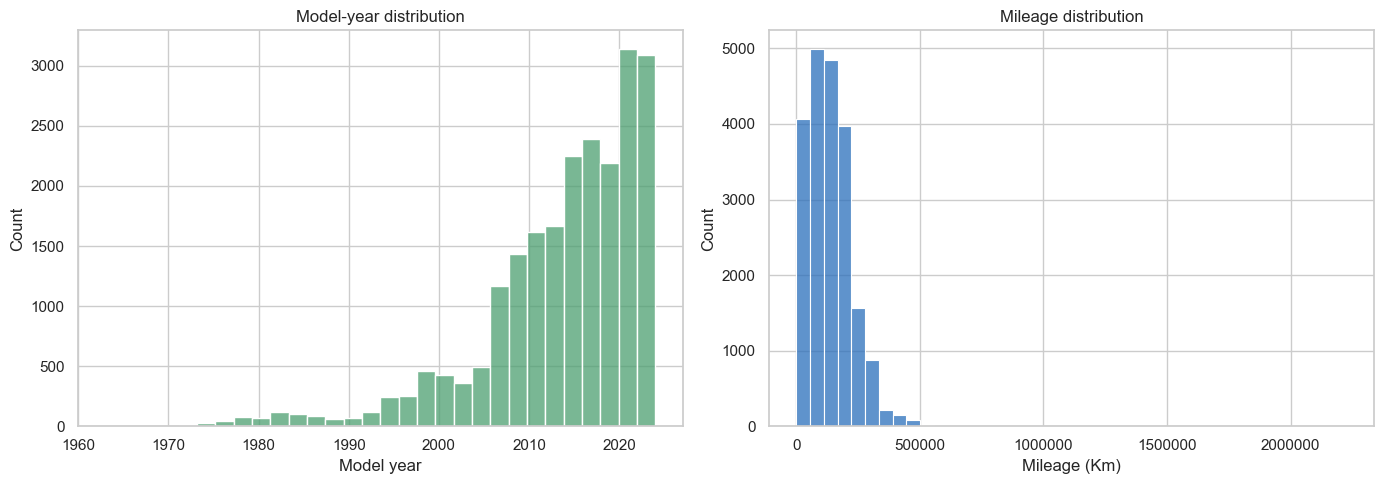

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean["year"], bins=30, ax=axes[0], color="#4c9f70")
axes[0].set_title("Model-year distribution")
axes[0].set_xlabel("Model year")

sns.histplot(df_clean["mileage"].dropna(), bins=40, ax=axes[1], color="#2a6fbb")
axes[1].set_title("Mileage distribution")
axes[1].set_xlabel("Mileage (Km)")
axes[1].ticklabel_format(style="plain", axis="x")

plt.tight_layout()
plt.show()


## 9. Correlation

Correlation gives a quick view of linear relationships between numerical columns. Correlation is not causation, and it cannot fully represent categorical columns such as make and model.


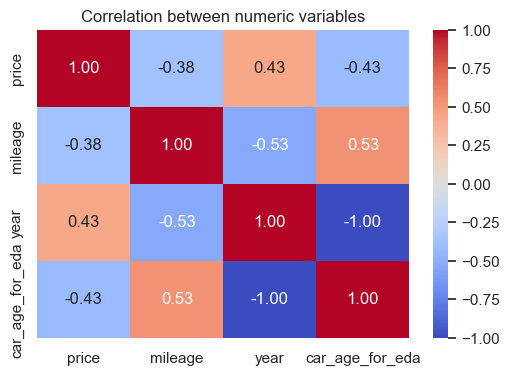

,price,mileage,year,car_age_for_eda
price,1.000000,-0.376210,0.425365,-0.425365
mileage,-0.376210,1.000000,-0.532558,0.532558
year,0.425365,-0.532558,1.000000,-1.000000
car_age_for_eda,-0.425365,0.532558,-1.000000,1.000000


In [18]:
correlation_columns = ["price", "mileage", "year", "car_age_for_eda"]
correlation = df_clean[correlation_columns].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation between numeric variables")
plt.show()

correlation


## 10. Feature engineering

We create two small, meaningful model features:

- car_age: how old the vehicle is in the 2024 listing dataset.
- mileage_per_year: total mileage adjusted for age.

For a new car, the denominator is at least one, avoiding division by zero. Missing mileage remains missing and will be handled inside the training pipeline.


In [19]:
df_clean["car_age"] = REFERENCE_YEAR - df_clean["year"]
df_clean["mileage_per_year"] = df_clean["mileage"] / df_clean["car_age"].clip(lower=1)

df_clean[["year", "car_age", "mileage", "mileage_per_year"]].head()


,year,car_age,mileage,mileage_per_year
0,2024.0,0.0,300.0,300.000000
2,2021.0,3.0,131000.0,43666.666667
3,2021.0,3.0,125000.0,41666.666667
4,2018.0,6.0,84000.0,14000.000000
5,2021.0,3.0,75000.0,25000.000000


## 11. Prepare data for Machine Learning

We keep characteristics a user can enter in the app. We exclude raw Price and numeric price because they reveal the target. We also exclude Item URL, Name, and Date Displayed because they are identifiers, unstructured duplicate information, or a listing timestamp rather than core car characteristics.


In [20]:
numeric_features = ["mileage", "car_age", "mileage_per_year"]

categorical_features = [
    "Make",
    "Model",
    "Color",
    "City",
    "Automatic Transmission",
    "Air Conditioner",
    "Power Steering",
    "Remote Control",
]

feature_columns = numeric_features + categorical_features

X = df_clean[feature_columns]
y = df_clean["price"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
X.head()


Feature matrix shape: (21974, 11)
Target shape: (21974,)


,mileage,car_age,mileage_per_year,Make,Model,Color,City,Automatic Transmission,Air Conditioner,Power Steering,Remote Control
0,300.0,0.0,300.000000,Kia,Sportage,Dark grey,Tagamo3 - New Cairo,Yes,Yes,Yes,Yes
2,131000.0,3.0,43666.666667,Fiat,Tipo,Petroleum,Kafr el-Dawwar,Yes,Yes,Yes,Yes
3,125000.0,3.0,41666.666667,Hyundai,Tucson Turbo GDI,Black,Nasr city,Yes,Yes,Yes,Yes
4,84000.0,6.0,14000.000000,BMW,X1,Gray,Cairo,Yes,Yes,Yes,Yes
5,75000.0,3.0,25000.000000,Chevrolet,Optra,Blue,Obour City,Yes,Yes,Yes,Yes


## 12. Train/test split

Training data teaches patterns. The test data is held aside for fair evaluation on unseen listings. We do not train on the test set.


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])


Training rows: 17579
Test rows: 4395


## 13. Handle missing and categorical features

Models need numeric input. The preprocessor fills missing numeric values with the training-set median, fills missing categories with the most common training category, and one-hot encodes text categories into 0/1 columns.

Because this preprocessor is inside each pipeline and is fitted only on the training data, it helps prevent data leakage from the test set.


In [22]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    sparse_threshold=0,
)

preprocessor


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 14. Model 1 — Linear Regression

Linear Regression is the baseline. It is simple, fast, and gives us a reference point before trying tree-based models.


In [23]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression()),
    ]
)

linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = mean_squared_error(y_test, linear_predictions) ** 0.5
linear_r2 = r2_score(y_test, linear_predictions)

print(f"Linear Regression MAE:  EGP {linear_mae:,.0f}")
print(f"Linear Regression RMSE: EGP {linear_rmse:,.0f}")
print(f"Linear Regression R²:   {linear_r2:.3f}")


Linear Regression MAE:  EGP 221,828
Linear Regression RMSE: EGP 526,995
Linear Regression R²:   0.699


## 15. Model 2 — Random Forest

A Random Forest combines many decision trees. It can learn non-linear relationships and interactions, such as model year meaning different things for different makes. The settings are modest on purpose; this is model comparison, not a hyperparameter competition.


In [24]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=120,
                min_samples_leaf=2,
                max_features=0.7,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

random_forest_model.fit(X_train, y_train)
random_forest_predictions = random_forest_model.predict(X_test)

random_forest_mae = mean_absolute_error(y_test, random_forest_predictions)
random_forest_rmse = mean_squared_error(y_test, random_forest_predictions) ** 0.5
random_forest_r2 = r2_score(y_test, random_forest_predictions)

print(f"Random Forest MAE:  EGP {random_forest_mae:,.0f}")
print(f"Random Forest RMSE: EGP {random_forest_rmse:,.0f}")
print(f"Random Forest R²:   {random_forest_r2:.3f}")


Random Forest MAE:  EGP 169,740
Random Forest RMSE: EGP 489,536
Random Forest R²:   0.740


## 16. Model 3 — Gradient Boosting

Gradient Boosting builds trees one after another, with each tree improving earlier errors. We keep this classroom model small and readable.


In [25]:
gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=35,
                learning_rate=0.10,
                max_depth=3,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

gradient_boosting_model.fit(X_train, y_train)
gradient_boosting_predictions = gradient_boosting_model.predict(X_test)

gradient_boosting_mae = mean_absolute_error(y_test, gradient_boosting_predictions)
gradient_boosting_rmse = mean_squared_error(y_test, gradient_boosting_predictions) ** 0.5
gradient_boosting_r2 = r2_score(y_test, gradient_boosting_predictions)

print(f"Gradient Boosting MAE:  EGP {gradient_boosting_mae:,.0f}")
print(f"Gradient Boosting RMSE: EGP {gradient_boosting_rmse:,.0f}")
print(f"Gradient Boosting R²:   {gradient_boosting_r2:.3f}")


Gradient Boosting MAE:  EGP 305,827
Gradient Boosting RMSE: EGP 607,747
Gradient Boosting R²:   0.599


## 17. Model comparison

- MAE is the average absolute error in EGP. Lower is better.
- RMSE penalizes large errors more strongly. Lower is better.
- R² describes variation explained on the unseen test set. Higher is better.

We choose based on test performance, not on model complexity.


In [26]:
results = pd.DataFrame(
    {
        "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
        "MAE": [linear_mae, random_forest_mae, gradient_boosting_mae],
        "RMSE": [linear_rmse, random_forest_rmse, gradient_boosting_rmse],
        "R²": [linear_r2, random_forest_r2, gradient_boosting_r2],
    }
).sort_values("RMSE").reset_index(drop=True)

results.style.format({"MAE": "EGP {:,.0f}", "RMSE": "EGP {:,.0f}", "R²": "{:.3f}"})


,Model,MAE,RMSE,R²
0,Random Forest,"EGP 169,740","EGP 489,536",0.740
1,Linear Regression,"EGP 221,828","EGP 526,995",0.699
2,Gradient Boosting,"EGP 305,827","EGP 607,747",0.599


In [27]:
trained_models = {
    "Linear Regression": linear_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model,
}

test_predictions = {
    "Linear Regression": linear_predictions,
    "Random Forest": random_forest_predictions,
    "Gradient Boosting": gradient_boosting_predictions,
}

best_model_name = results.loc[0, "Model"]
best_model = trained_models[best_model_name]
best_predictions = test_predictions[best_model_name]

print("Selected model based on lowest test RMSE:", best_model_name)


Selected model based on lowest test RMSE: Random Forest


## 18. Actual vs. predicted

A good prediction plot has points close to the diagonal line. Points far from it are larger prediction errors.


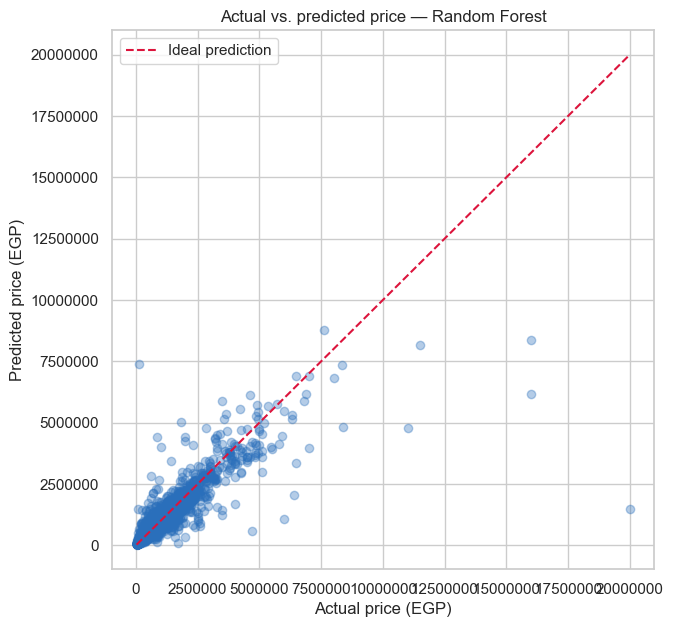

In [28]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_predictions, alpha=0.35, color="#2a6fbb")

line_min = min(y_test.min(), best_predictions.min())
line_max = max(y_test.max(), best_predictions.max())
plt.plot([line_min, line_max], [line_min, line_max], "--", color="crimson", label="Ideal prediction")

plt.title(f"Actual vs. predicted price — {best_model_name}")
plt.xlabel("Actual price (EGP)")
plt.ylabel("Predicted price (EGP)")
plt.ticklabel_format(style="plain")
plt.legend()
plt.show()


## 19. Error analysis

Metrics summarize all test rows, but individual errors show where a model struggles. We calculate absolute and percentage errors, then inspect the worst examples without inventing explanations.


In [29]:
error_analysis = X_test.reset_index(drop=True).copy()
error_analysis["Actual Price"] = y_test.reset_index(drop=True)
error_analysis["Predicted Price"] = best_predictions
error_analysis["Absolute Error"] = (
    error_analysis["Actual Price"] - error_analysis["Predicted Price"]
).abs()
error_analysis["Percentage Error"] = (
    error_analysis["Absolute Error"] / error_analysis["Actual Price"] * 100
)

error_analysis = error_analysis.sort_values("Absolute Error", ascending=False)

error_analysis[
    [
        "Make",
        "Model",
        "car_age",
        "mileage",
        "Actual Price",
        "Predicted Price",
        "Absolute Error",
        "Percentage Error",
    ]
].head(10).style.format(
    {
        "Actual Price": "EGP {:,.0f}",
        "Predicted Price": "EGP {:,.0f}",
        "Absolute Error": "EGP {:,.0f}",
        "Percentage Error": "{:.1f}%",
    }
)


,Make,Model,car_age,mileage,Actual Price,Predicted Price,Absolute Error,Percentage Error
3491,McLaren,GT,1.000000,nan,"EGP 20,000,000","EGP 1,482,115","EGP 18,517,885",92.6%
4390,Land Rover,Range Rover Vogue,0.000000,1.000000,"EGP 16,000,000","EGP 6,155,726","EGP 9,844,274",61.5%
3488,Porsche,Cayenne,1.000000,0.000000,"EGP 16,000,000","EGP 8,374,961","EGP 7,625,039",47.7%
1768,Porsche,Cayenne,0.000000,nan,"EGP 117,000","EGP 7,371,236","EGP 7,254,236",6200.2%
1103,Mercedes,S 450,1.000000,22000.000000,"EGP 11,000,000","EGP 4,791,864","EGP 6,208,136",56.4%
2354,Land Rover,Range Rover Evoque,8.000000,102000.000000,"EGP 6,000,000","EGP 1,060,924","EGP 4,939,076",82.3%
3682,Nissan,Patrol,5.000000,50000.000000,"EGP 6,400,000","EGP 2,065,782","EGP 4,334,218",67.7%
2339,Nissan,Patrol,11.000000,170000.000000,"EGP 4,700,000","EGP 577,114","EGP 4,122,886",87.7%
1999,BMW,X5 M,1.000000,23.000000,"EGP 8,400,000","EGP 4,812,001","EGP 3,587,999",42.7%
3103,Mercedes,GLA,0.000000,nan,"EGP 850,000","EGP 4,405,739","EGP 3,555,739",418.3%


In [30]:
error_by_make = (
    error_analysis.groupby("Make")
    .agg(
        test_listings=("Actual Price", "size"),
        median_absolute_error=("Absolute Error", "median"),
    )
    .query("test_listings >= 15")
    .sort_values("median_absolute_error", ascending=False)
    .head(10)
)

error_by_make.style.format({"median_absolute_error": "EGP {:,.0f}"})


,test_listings,median_absolute_error
Make,,
Mercedes,203,"EGP 332,910"
BMW,139,"EGP 231,327"
Jac,24,"EGP 169,680"
Citroën,49,"EGP 136,788"
MG,110,"EGP 125,588"
Proton,16,"EGP 118,090"
Jeep,51,"EGP 107,737"
Chery,144,"EGP 99,339"
Toyota,199,"EGP 92,910"


### Interpretation

Use the displayed error table to guide discussion. Large errors can occur for expensive luxury listings, rare models, unusual attribute combinations, or condition details not present in this dataset. These are data-informed possibilities, not proof about every listing.


## 20. Feature importance

A tree model can report which transformed features were most useful for reducing error. Importance means useful for prediction in this fitted model; it does not prove causation.


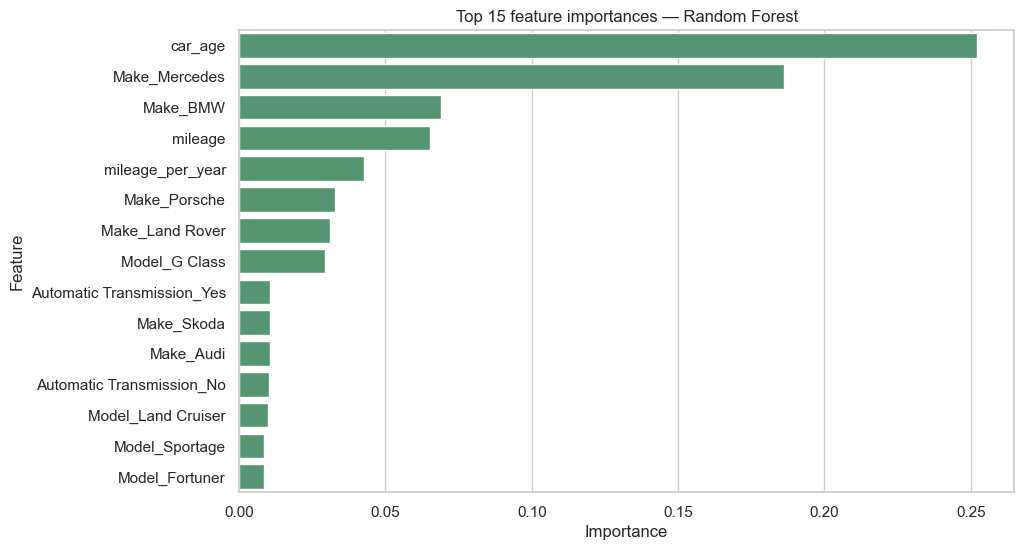

In [31]:
if best_model_name in ["Random Forest", "Gradient Boosting"]:
    fitted_preprocessor = best_model.named_steps["preprocessor"]
    transformed_feature_names = fitted_preprocessor.get_feature_names_out()

    clean_feature_names = (
        pd.Series(transformed_feature_names)
        .str.replace("num__", "", regex=False)
        .str.replace("cat__", "", regex=False)
    )

    feature_importance = pd.DataFrame(
        {
            "Feature": clean_feature_names,
            "Importance": best_model.named_steps["model"].feature_importances_,
        }
    ).sort_values("Importance", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=feature_importance.head(15),
        x="Importance",
        y="Feature",
        color="#4c9f70",
    )
    plt.title(f"Top 15 feature importances — {best_model_name}")
    plt.show()

    feature_importance.head(15)
else:
    feature_importance = pd.DataFrame(columns=["Feature", "Importance"])
    print("The selected model is linear, so tree feature importance is unavailable.")


## 21. Final model and saved files

After fair selection using the held-out test data, we fit the selected pipeline on all cleaned listings. The saved pipeline contains both preprocessing and the model, so the apps transform user inputs exactly as the model expects.


In [32]:
# Refit the selected pipeline on all cleaned data for the apps.
best_model.fit(X, y)

joblib.dump(best_model, "models/model.pkl")
joblib.dump(best_model.named_steps["preprocessor"], "models/preprocessor.pkl")
results.to_csv("models/model_results.csv", index=False)

if not feature_importance.empty:
    feature_importance.to_csv("models/feature_importance.csv", index=False)

print("Saved models/model.pkl")
print("Saved models/preprocessor.pkl")
print("Saved models/model_results.csv")
print("Saved models/feature_importance.csv")


Saved models/model.pkl
Saved models/preprocessor.pkl
Saved models/model_results.csv
Saved models/feature_importance.csv


## 22. Final prediction demo

These manually entered example cars use categories that exist in the supplied dataset. Their engineered values are calculated exactly as they are in the app.


In [33]:
example_cars = pd.DataFrame(
    {
        "mileage": [90_000, 130_000, 50_000],
        "car_age": [2024 - 2018, 2024 - 2016, 2024 - 2021],
        "mileage_per_year": [
            90_000 / max(2024 - 2018, 1),
            130_000 / max(2024 - 2016, 1),
            50_000 / max(2024 - 2021, 1),
        ],
        "Make": ["Nissan", "Fiat", "Hyundai"],
        "Model": ["Sunny", "Tipo", "Elantra HD"],
        "Color": ["White", "Black", "Silver"],
        "City": ["Cairo", "Cairo", "Cairo"],
        "Automatic Transmission": ["Yes", "Yes", "Yes"],
        "Air Conditioner": ["Yes", "Yes", "Yes"],
        "Power Steering": ["Yes", "Yes", "Yes"],
        "Remote Control": ["Yes", "Yes", "Yes"],
    }
)

example_cars["Predicted Price (EGP)"] = best_model.predict(example_cars).round(0)
example_cars[["Make", "Model", "car_age", "mileage", "Predicted Price (EGP)"]]


,Make,Model,car_age,mileage,Predicted Price (EGP)
0,Nissan,Sunny,6,90000,539062.0
1,Fiat,Tipo,8,130000,730355.0
2,Hyundai,Elantra HD,3,50000,782406.0


## 23. Final Data Science insights

The displayed charts and tables support these evidence-based findings:

- Listing prices are right-skewed, with a small number of expensive listings extending the range.
- Car age and mileage provide useful signals, but their scatter shows they do not explain price alone.
- Make and model help distinguish different market segments.
- Comparing three models tests whether non-linear patterns improve on a simple baseline.
- Error analysis reminds us that one score cannot describe performance for every vehicle.

When presenting the project, connect each statement to the notebook output rather than treating it as a universal rule.
